# **Assignment 1 : Group n°29**


In [3]:
!pip install linopy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


a) Choose one country/region/city/system and calculate the optimal capacities for renewable and non-
renewable generators. You can add as many technologies as you want. Remember to provide a reference
for the costs and other technological assumptions

In [4]:
# Imports
import os
import certifi

os.environ['SSL_CERT_FILE'] = certifi.where()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import linopy as lp
import xarray as xr
from rasterio.rio.helpers import coords

In [5]:
# New data granularity filter
df = pd.read_csv('ods001.csv', sep=';')
df['Datetime'] = pd.to_datetime(df['Datetime'], utc=True)
df = df.sort_values(by=['Datetime'], ascending=True)

df_load = df[
    (df['Datetime'].dt.minute == 0) &
    (df['Datetime'].dt.second == 0)
]

df_load = df_load.rename(columns={'Datetime': 'utc_time'})
df_load.to_csv('df_load.csv', index=False)

print(df_load.head())

                        utc_time Resolution code  Total Load  \
253936 2014-12-31 23:00:00+00:00           PT15M    10142.19   
253933 2015-01-01 00:00:00+00:00           PT15M     9755.00   
347882 2015-01-01 01:00:00+00:00           PT15M     9349.16   
253929 2015-01-01 02:00:00+00:00           PT15M     8926.36   
253926 2015-01-01 03:00:00+00:00           PT15M     8612.22   

        Most recent forecast  Most recent P10  Most recent P90  \
253936               9496.05          8871.71         10120.38   
253933               9222.33          8880.23          9564.44   
347882               8781.47          8445.07          9117.87   
253929               8413.84          8075.81          8751.87   
253926               8190.19          7853.67          8526.72   

        Day-ahead 6PM forecast  Day-ahead 6PM P10  Day-ahead 6PM P90  \
253936                 9697.59            9076.64           10318.53   
253933                10130.36            9777.87           10482.86   
34

In [6]:
# Load the data (assuming df_load.csv was created by your previous code)
df_load = pd.read_csv('df_load.csv')
df_load['utc_time'] = pd.to_datetime(df_load['utc_time'], utc=True)

# Identify the most recent year and the cutoff
max_year = df_load['utc_time'].dt.year.max() - 1
cutoff_year = max_year - 2

# Filter for the three most recent years (e.g., 2024, 2023, 2022)
df_recent = df_load[df_load['utc_time'].dt.year >= cutoff_year].copy()

# Save the result
df_recent.to_csv('df_recent.csv', index=False)

# Display the first few rows and the date range to verify
print(f"Data filtered from {cutoff_year} to {max_year}")
print(df_recent.head())

Data filtered from 2023 to 2025
                       utc_time Resolution code  Total Load  \
70129 2023-01-01 00:00:00+00:00           PT15M     7223.97   
70130 2023-01-01 01:00:00+00:00           PT15M     6895.73   
70131 2023-01-01 02:00:00+00:00           PT15M     6670.86   
70132 2023-01-01 03:00:00+00:00           PT15M     6432.72   
70133 2023-01-01 04:00:00+00:00           PT15M     6491.17   

       Most recent forecast  Most recent P10  Most recent P90  \
70129               7381.91          7032.70          7731.12   
70130               7026.03          6679.42          7372.64   
70131               6842.45          6496.24          7188.67   
70132               6653.89          6311.93          6995.84   
70133               6710.18          6367.24          7053.12   

       Day-ahead 6PM forecast  Day-ahead 6PM P10  Day-ahead 6PM P90  \
70129                 7790.96            7480.15            8101.77   
70130                 7402.86            7094.33        

In [7]:
# 1. Load and Filter Demand (3 most recent years)
df_load = pd.read_csv('df_load.csv')
df_load['utc_time'] = pd.to_datetime(df_load['utc_time'], utc=True)
max_year = df_load['utc_time'].dt.year.max() - 1
df_load_recent = df_load[df_load['utc_time'].dt.year >= (max_year - 2)].copy()

# 2. Load Renewables
# Note: Added 'usecols' to save memory and only get what we need
df_onshore = pd.read_csv("onshore_wind_1979-2017.csv", sep=';')
df_offshore = pd.read_csv("offshore_wind_1979-2017.csv", sep=';')
df_solar = pd.read_csv("pv_optimal.csv", sep=';')


def get_recent_cf_years(df, value_col_name):
    """
    Instead of averaging, picks the 3 most recent historical years
    and prepares them for mapping by relative year offset.
    """
    df['utc_time'] = pd.to_datetime(df['utc_time'], utc=True)
    max_hist_year = df['utc_time'].dt.year.max()

    # Get last 3 years of history (e.g., 2015, 2016, 2017)
    df_recent = df[df['utc_time'].dt.year >= (max_hist_year - 2)].copy()

    # Create a relative year index (0, 1, 2)
    min_y = df_recent['utc_time'].dt.year.min()
    df_recent['rel_year'] = df_recent['utc_time'].dt.year - min_y
    df_recent['month'] = df_recent['utc_time'].dt.month
    df_recent['day'] = df_recent['utc_time'].dt.day
    df_recent['hour'] = df_recent['utc_time'].dt.hour

    return df_recent[['rel_year', 'month', 'day', 'hour', 'BEL']].rename(columns={'BEL': value_col_name})

# 2. Prepare CF Data (Mapping 1-to-1 year instead of averaging)
onshore_recent = get_recent_cf_years(df_onshore, 'onshore_wind_cf')
offshore_recent = get_recent_cf_years(df_offshore, 'offshore_wind_cf')
solar_recent = get_recent_cf_years(df_solar, 'solar_cf')

# 3. Prepare Load DF with relative year index
min_load_y = df_load_recent['utc_time'].dt.year.min()
df_load_recent['rel_year'] = df_load_recent['utc_time'].dt.year - min_load_y
df_load_recent['month'] = df_load_recent['utc_time'].dt.month
df_load_recent['day'] = df_load_recent['utc_time'].dt.day
df_load_recent['hour'] = df_load_recent['utc_time'].dt.hour

# 4. Merge using relative year + MDH (Preserves inter-annual variability)
df_merged = df_load_recent.merge(onshore_recent, on=['rel_year', 'month', 'day', 'hour'], how='left') \
    .merge(offshore_recent, on=['rel_year', 'month', 'day', 'hour'], how='left') \
    .merge(solar_recent, on=['rel_year', 'month', 'day', 'hour'], how='left')

# 5. Handle Leap Year Mismatches
# (e.g., If 2024 is a leap year but the mapped historical year wasn't)
df_merged = df_merged.ffill().bfill()

# 6. Cleanup
df_merged = df_merged.drop(columns=['rel_year', 'month', 'day', 'hour'])
df_merged.columns = [c.replace(' ', '_').lower() for c in df_merged.columns]
df_merged = df_merged[['utc_time', 'total_load', 'offshore_wind_cf', 'onshore_wind_cf', 'solar_cf']]



In [8]:
cf_2023 = df_merged[df_merged['utc_time'].dt.year == 2023]
cf_2024 = df_merged[df_merged['utc_time'].dt.year == 2024]
cf_2025 = df_merged[df_merged['utc_time'].dt.year == 2025]

cf_2023
#cf_2024
#cf_2025

,utc_time,total_load,offshore_wind_cf,onshore_wind_cf,solar_cf
0,2023-01-01 00:00:00+00:00,7223.97,0.810,0.095,0.0
1,2023-01-01 01:00:00+00:00,6895.73,0.857,0.126,0.0
2,2023-01-01 02:00:00+00:00,6670.86,0.852,0.164,0.0
3,2023-01-01 03:00:00+00:00,6432.72,0.839,0.173,0.0
4,2023-01-01 04:00:00+00:00,6491.17,0.824,0.173,0.0
...,...,...,...,...,...
8755,2023-12-31 19:00:00+00:00,8339.15,0.918,0.359,0.0
8756,2023-12-31 20:00:00+00:00,8103.94,0.919,0.382,0.0
8757,2023-12-31 21:00:00+00:00,7915.43,0.916,0.368,0.0
8758,2023-12-31 22:00:00+00:00,7862.32,0.892,0.371,0.0


| Technology    | Efficiency (%) | Total CAPEX (EUR/MW) | Fixed O&M (EUR/MW/yr) | Annualized CAPEX (EUR/MW/yr) | Marginal Cost (EUR/MWh) |
|:--------------| :--- |:---------------------|:----------------------|:-----------------------------| :--- |
| CCGT          | 63% | 1,061,000            | 25,000                | 54,111                       | 63.02 |
| OCGT          | 42% | 705,000              | 24,000                | 47,235                       | 95.03 |
| PV Industrial | — | 1,383,000            | 18,000                | 79,353                       | 0.00 |
| Onshore Wind  | — | 1,388,000            | 40,000                | 70,788                       | 0.00 |
| Offshore Wind | — | 2,200,000            | 55,000                | 112,185                      | 0.00 |
| Nuclear       | 33% | 1,240,000            | 53,000                | 145,366                      | 10.00 |
| Coal          | 42% | 2,500,000            | 60,000                | 127,483                      | 45.00 |

Table of costs -> NOW FROM PYPSA DATA

---

### **Annualization Logic**

The **Annualized CAPEX** represents the "yearly installment" required to recover the initial investment over the asset's technical life, accounting for the time value of money.
-> NOW FROM PYPSA DATA

It is calculated using the **Capital Recovery Factor (CRF)**:

$$\text{Annualized CAPEX} = \text{CAPEX} \times \frac{r(1+r)^n}{(1+r)^n - 1}$$

**Where:**
* **$r = 0.03$** (3% discount rate, as per EnergyVille assumptions).
* **$n$** is the technical lifetime of the technology.

**Lifetimes ($n$):** -> NOW FROM PYPSA DATA
* **CCGT / Onshore Wind / Solar PV:** $30$ years.
* **OCGT:** $20$ years.

### **Thermal Technologies (CCGT & OCGT)**

The **Marginal Cost (MC)** for gas plants represents the variable cost of producing one additional MWh of electricity. It is calculated using the following formula:

$$MC = \frac{\text{Fuel Price} + (\text{Emission Factor} \times \text{CO}_2 \text{ Price})}{\text{Efficiency}} + \text{VOM}$$

Based on the **EnergyVille 2025/2026** assumptions:

* **Natural Gas Price:** $\approx 25.92 \text{ EUR/MWh}$ -> NOW FROM PYPSA DATA
* **$\text{CO}_2$ Price (ETS):** $\approx 62 \text{ EUR/ton}$ (Note: PATHS2050 projects this to rise steeply to $186 \text{ EUR}$ by 2030).
* **Emission Factor:** $0.202 \text{ tons of CO}_2$ per MWh of gas burned.
* **VOM (Variable O&M):** Costs associated with wear and tear per unit of generation. -> NOW FROM PYPSA DATA

source: https://perspective2050.energyville.be/results/main-edition-2025/assumptions

In [9]:
#Get costs data from PyPSA technology data for 2025

url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_2025.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "discount rate": 0.03,
    "CO2 intensity": 0
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = 0.202 #tCO2eq/MWh
costs.at["CCGT", "CO2 intensity"] = 0.202 #tCO2eq/MWh


def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

costs["Marginal_Cost_(EUR/MWh)"] = costs["VOM"] + (costs["fuel"]+costs["CO2 intensity"]*62) / costs["efficiency"]

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)

costs["Annualized_CAPEX_(EUR/MW/yr)"] = (annuity + costs["FOM"] / 100) * costs["investment"]

In [10]:
#Create a smaller data frame with the info we want

df_techno = costs[['Annualized_CAPEX_(EUR/MW/yr)','Marginal_Cost_(EUR/MWh)','efficiency']]

print("Available technology names in costs DataFrame:")
print(costs.index.get_level_values('technology').unique())

desired_techs = ['CCGT', 'OCGT', 'solar', 'onwind', 'offwind', 'nuclear', 'coal']
df_techno = df_techno.loc[desired_techs]
# Reset the index to make 'technology' a regular column
df_techno = df_techno.reset_index()
# Rename the 'index' column to 'Technology' for clarity
df_techno = df_techno.rename(columns={'index': 'Technology'})
df_techno

Available technology names in costs DataFrame:
Index(['Alkaline electrolyzer', 'Ammonia cracker', 'BEV Bus city', 'BEV Coach',
       'BEV Truck Semi-Trailer max 50 tons', 'BEV Truck Solo max 26 tons',
       'BEV Truck Trailer max 56 tons', 'Battery electric (passenger cars)',
       'Battery electric (trucks)', 'BioSNG',
       ...
       'solar-utility single-axis tracking', 'solid biomass',
       'solid biomass boiler steam', 'solid biomass boiler steam CC',
       'solid biomass to hydrogen', 'uranium', 'waste CHP', 'waste CHP CC',
       'water tank charger', 'water tank discharger'],
      dtype='str', name='technology', length=294)


parameter,technology,Annualized_CAPEX_(EUR/MW/yr),Marginal_Cost_(EUR/MWh),efficiency
0,CCGT,82171.957509,69.624084,0.570
1,OCGT,35386.079709,96.347185,0.405
2,solar,41985.041823,0.010600,1.000
3,onwind,74137.975600,1.508000,1.000
4,offwind,132259.653164,0.021200,1.000
5,nuclear,480948.252897,14.013271,0.326
6,coal,215708.001618,88.633110,0.356


In [11]:
# Set up and solve the LP

# 1. Setup Model and Data
m = lp.Model()
time = df_merged['utc_time']
techs = df_techno['technology'].to_list() # Convert to list for explicit coordinates

# Cost parameters from Table 1
# Convert to xarray DataArray for explicit coordination with 'techs'
capital_costs = xr.DataArray(df_techno['Annualized_CAPEX_(EUR/MW/yr)'].values, coords=[techs], dims=['tech'])
marginal_costs = xr.DataArray(df_techno['Marginal_Cost_(EUR/MWh)'].values, coords=[techs], dims=['tech'])

# Capacity factors and demand as xarrays
tech_efficiency_map = df_techno.set_index('technology')['efficiency']
CF = []
for t in techs :
  if t == 'onwind' :
    CF.append(df_merged['onshore_wind_cf'])
  elif t == 'offwind' :
    CF.append(df_merged['offshore_wind_cf'])
  elif t == 'solar':
    CF.append(df_merged['solar_cf'])
  else :
    #CF.append(pd.Series([tech_efficiency_map.loc[t]] * len(time), index=time))
    CF.append([0.9]*len(time))

cf = xr.DataArray(CF, coords=[techs, time], dims=['tech', 'time'])
demand = xr.DataArray(df_merged['total_load'], coords=[time], dims=['time'])

# 2. Variables
# Capacity (G) per technology (MW)
capacity = m.add_variables(coords=[techs], dims=['tech'], name='capacity', lower=0)
# Generation (g) per tech per hour (MWh)
gen = m.add_variables(coords=[techs, time], dims=['tech', 'time'], name='gen', lower=0)

# 3. Constraints
# Energy Balance: Sum of generation must equal demand at each hour
m.add_constraints((gen.sum('tech') == demand), name='balance')

# Capacity Constraint: Generation cannot exceed installed capacity * capacity factor
m.add_constraints((gen <= capacity * cf), name='cap_limit')

# 4. Objective Function
# Minimize (Total Capital Costs + Total Variable Costs)
obj = (capacity * 3 * capital_costs).sum() + (gen * marginal_costs).sum().sum() # capital_costs and marginal_costs are now xr.DataArrays
m.add_objective(obj)

# 5. Solve
m.solve(solver_name='highs')

Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 104.58it/s]


('ok', 'optimal')

Extraction of optimal installed capacities for every technology

In [12]:
# 6. Results Extraction
opt_capacity = capacity.solution.to_series()
total_gen = gen.solution.sum('time').to_series()
total_cost = m.objective.value

print(f"Total System Cost: {total_cost:,.2f} EUR")
print("\nAnnual Generation per Technology (MWh):")
for tech, value in total_gen.items():
    print(f"{tech:7}: {value:15,.2f}")

print("\nOptimal Capacities (MW):\n", opt_capacity)

Total System Cost: 15,673,264,867.46 EUR

Annual Generation per Technology (MWh):
CCGT   :   83,419,320.78
OCGT   :    8,802,499.10
solar  :   42,290,942.34
onwind :            0.00
offwind:  125,707,662.07
nuclear:            0.00
coal   :            0.00

Optimal Capacities (MW):
 tech
CCGT        7385.528542
OCGT        6598.561884
solar      13712.156054
onwind        -0.000000
offwind    12011.230893
nuclear        0.000000
coal           0.000000
Name: solution, dtype: float64


In [13]:
# Convert the xarray solution to a DataFrame for easier manipulation
df_gen = gen.solution.to_dataframe('generation').reset_index()

# Ensure 'time' is datetime objects
df_gen['time'] = pd.to_datetime(df_gen['time'])

# Extract Year and sum generation
annual_gen = df_gen.groupby([df_gen['time'].dt.year, 'tech'])['generation'].sum()

print("Annual Generation per Year/Tech (MWh):")
print(annual_gen)

Annual Generation per Year/Tech (MWh):
time  tech   
2023  CCGT       2.482001e+07
      OCGT       2.257990e+06
      coal       0.000000e+00
      nuclear    0.000000e+00
      offwind    3.761648e+07
      onwind     0.000000e+00
      solar      1.428390e+07
2024  CCGT       2.895117e+07
      OCGT       3.120148e+06
      coal       0.000000e+00
      nuclear    0.000000e+00
      offwind    3.464460e+07
      onwind     0.000000e+00
      solar      1.431032e+07
2025  CCGT       2.883247e+07
      OCGT       3.424361e+06
      coal       0.000000e+00
      nuclear    0.000000e+00
      offwind    3.444776e+07
      onwind     0.000000e+00
      solar      1.369672e+07
2026  CCGT       8.156787e+05
      OCGT       0.000000e+00
      coal       0.000000e+00
      nuclear    0.000000e+00
      offwind    1.899882e+07
      onwind     0.000000e+00
      solar      0.000000e+00
Name: generation, dtype: float64


In [14]:
years = [2023, 2024, 2025]
yearly_sensitivities = {}
yearly_gen_sums = {} # Dictionary to store annual generation totals

yearly_cf_on={}
yearly_cf_off={}
yearly_cf_s={}

gen_solutions = {}
demand_data = {}

for year in years:
    print(f"--- Optimizing for Year {year} ---")

    # 1. Prepare data
    df_y = df_merged[df_merged['utc_time'].dt.year == year].copy()
    time_c = df_y['utc_time'].values

    # 2. Build correctly shaped 2D array
    CF_yearly = []
    current_len = len(df_y)
    for t in techs:
        if t == 'onwind':
          CF_yearly.append(df_y['onshore_wind_cf'].values)
          yearly_cf_on[year] = df_y['onshore_wind_cf'].values.mean()
        elif t == 'offwind':
          CF_yearly.append(df_y['offshore_wind_cf'].values)
          yearly_cf_off[year] = df_y['offshore_wind_cf'].values.mean()
        elif t == 'solar':
          CF_yearly.append(df_y['solar_cf'].values)
          yearly_cf_s[year] = df_y['solar_cf'].values.mean()
        else: CF_yearly.append(np.full(current_len, 0.8))

    # 3. Create DataArrays with explicit coordinates
    # This aligns the cost arrays with the techs
    cf_xr = xr.DataArray(np.array(CF_yearly), coords={'tech': techs, 'time': time_c}, dims=('tech', 'time'))
    demand_xr = xr.DataArray(df_y['total_load'].values, coords={'time': time_c}, dims=('time'))

    # 4. Initialize and Solve
    m = lp.Model()

    # Pass the coords explicitly to the variables so linopy knows the labels
    cap = m.add_variables(coords=capital_costs.coords, name='capacity', lower=0)
    gen = m.add_variables(coords=cf_xr.coords, name='gen', lower=0)

    # 5. Constraints and Objective
    m.add_constraints(gen.sum('tech') == demand_xr, name='balance')
    m.add_constraints(gen <= cap * cf_xr, name='cap_limit')

    m.add_objective((cap * capital_costs).sum() + (gen * marginal_costs).sum())
    m.solve(solver_name='highs')

    yearly_sensitivities[year] = cap.solution.to_series()
    yearly_gen_sums[year] = gen.solution.sum('time').to_series()

    gen_solutions[year] = gen.solution.copy()
    demand_data[year] = demand_xr.copy()

--- Optimizing for Year 2023 ---


Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 45.68it/s]


--- Optimizing for Year 2024 ---


Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 171.58it/s]


--- Optimizing for Year 2025 ---


Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 170.66it/s]


In [15]:
df_res = pd.DataFrame(yearly_sensitivities)
print("\nOptimal Capacity per Year (MW):")
print(df_res)

df_gen_res = pd.DataFrame(yearly_gen_sums)
print("\nTotal Annual Generation per Technology (MWh):")
print(df_gen_res)


Optimal Capacity per Year (MW):
                 2023          2024          2025
tech                                             
CCGT      7355.448377   8233.321313   8304.422468
OCGT      7704.507476   6817.072406   7435.717697
solar    13227.987980  14659.390863  14461.210607
onwind       0.000000      0.000000      0.000000
offwind  11505.317572  11277.512248  11092.552598
nuclear      0.000000      0.000000      0.000000
coal         0.000000      0.000000      0.000000

Total Annual Generation per Technology (MWh):
                 2023          2024          2025
tech                                             
CCGT     2.439779e+07  2.946023e+07  2.981403e+07
OCGT     3.817133e+06  3.307375e+06  3.535770e+06
solar    1.381996e+07  1.521714e+07  1.437646e+07
onwind   0.000000e+00  0.000000e+00  0.000000e+00
offwind  3.694350e+07  3.304149e+07  3.267505e+07
nuclear  0.000000e+00  0.000000e+00  0.000000e+00
coal     0.000000e+00  0.000000e+00  0.000000e+00


Boxplots for sensitivity analysis

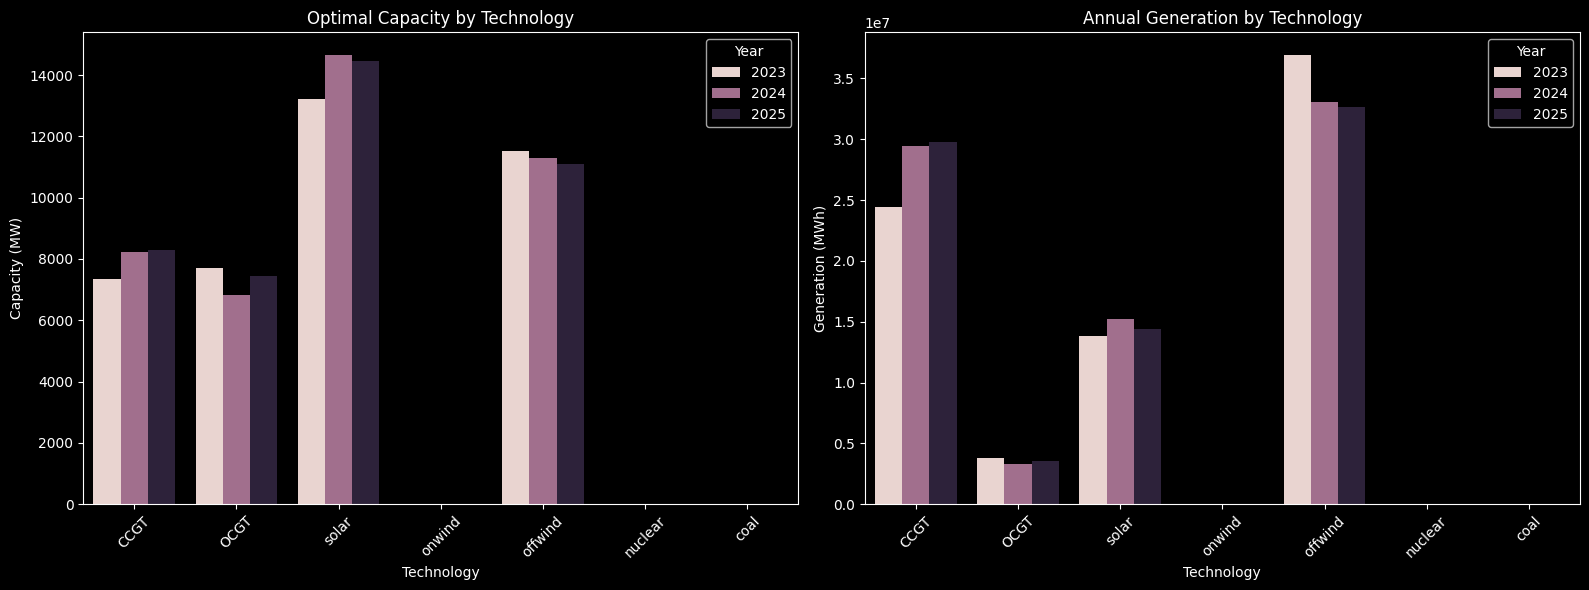

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data for plotting
# Transpose so 'Technology' is a column and 'Year' becomes a column
df_cap_long = df_res.T.reset_index().melt(id_vars='index', var_name='Technology', value_name='Capacity (MW)')
df_cap_long.rename(columns={'index': 'Year'}, inplace=True)

df_gen_long = df_gen_res.T.reset_index().melt(id_vars='index', var_name='Technology', value_name='Generation (MWh)')
df_gen_long.rename(columns={'index': 'Year'}, inplace=True)

# 2. Create the plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Column plot for Capacity
sns.barplot(data=df_cap_long, x='Technology', y='Capacity (MW)', hue='Year', ax=axes[0])
axes[0].set_title('Optimal Capacity by Technology')
axes[0].tick_params(axis='x', rotation=45)

# Column plot for Generation
sns.barplot(data=df_gen_long, x='Technology', y='Generation (MWh)', hue='Year', ax=axes[1])
axes[1].set_title('Annual Generation by Technology')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
#plt.savefig('optimization_results_barplots.png')

Plot the dispatch

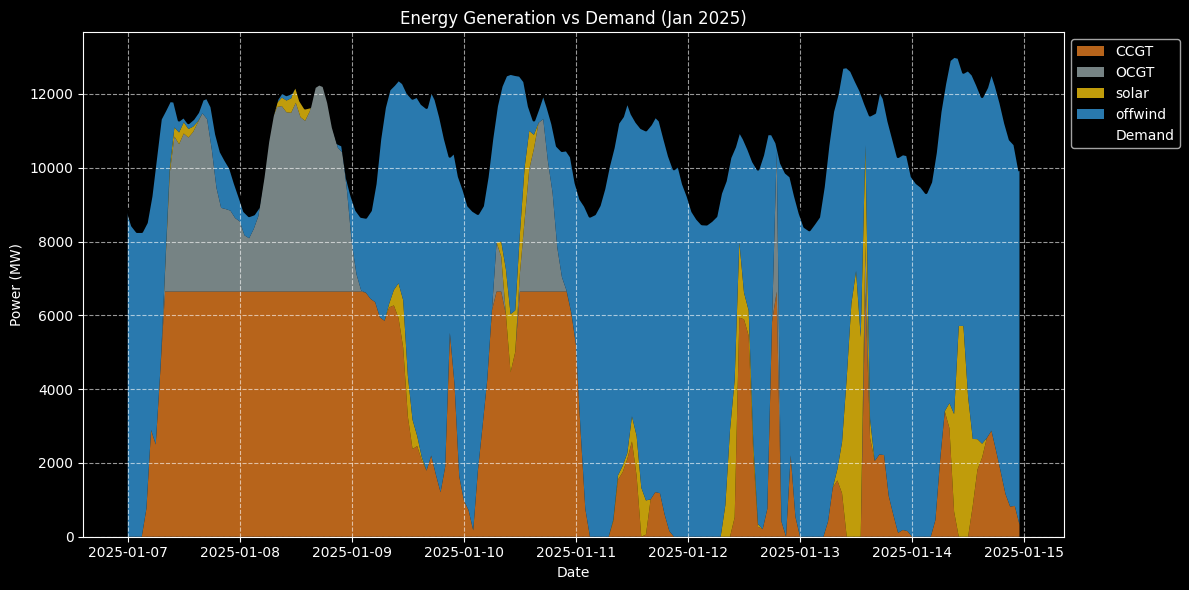

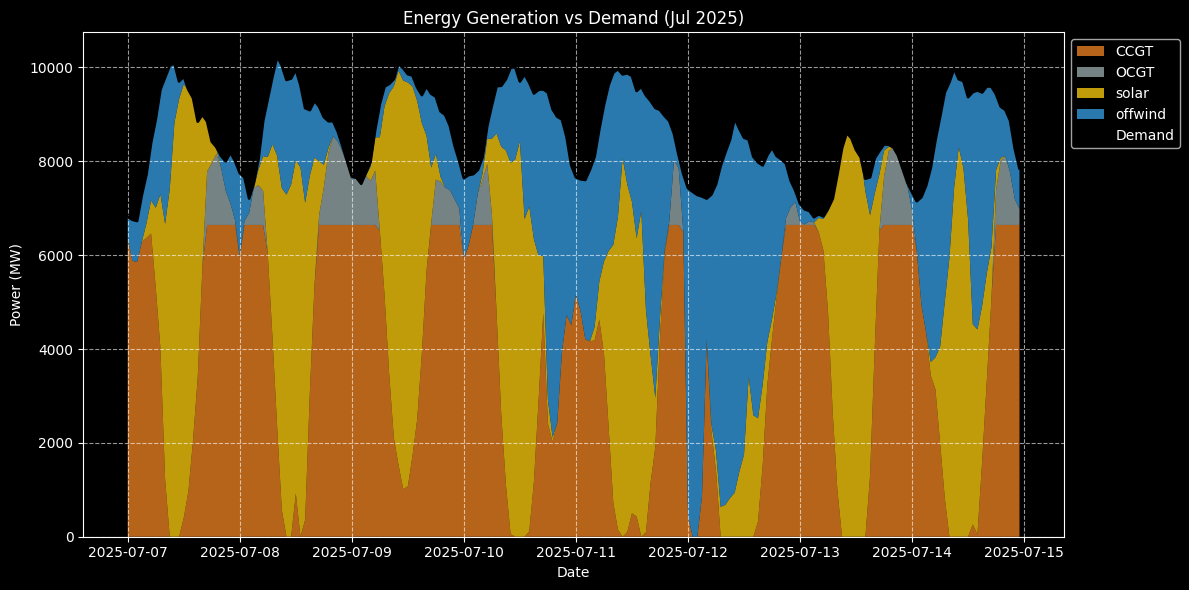

In [17]:
# Define function to get the period of interest data
'''
def get_period_data(start_date, end_date):
    """
    Extracts generation and demand for any period.
    Example: start_date='2015-02-01', end_date='2015-02-07'
    """
    # Slice the xarray using labels
    gen_slice = gen.solution.sel(time=slice(start_date, end_date)).to_pandas().T

    # Slice the demand (assuming it's the DataArray created earlier)
    demand_slice = demand.sel(time=slice(start_date, end_date)).to_series()

    return gen_slice, demand_slice
    '''

def get_period_data(gen_var, demand_arr, start_date, end_date):
    """
    gen_var: The 'gen' linopy variable solution (DataArray)
    demand_arr: The demand DataArray for that specific year
    """
    # Use .sel() on the DataArray directly
    gen_slice = gen_var.sel(time=slice(start_date, end_date)).to_pandas().T
    demand_slice = demand_arr.sel(time=slice(start_date, end_date)).to_series()

    return gen_slice, demand_slice

jan_gen, jan_demand = get_period_data(gen_solutions[2025], demand_data[2025], '2025-01-07', '2025-01-14')
jul_gen, jul_demand = get_period_data(gen_solutions[2025], demand_data[2025], '2025-07-07', '2025-07-14')

def plot_period(gen_data, demand_data, title, colors):
    """
    Plots stacked generation and demand, only showing non-zero technologies in the legend.
    """
    # 1. Identify technologies with non-zero generation in this slice
    active_techs = [tech for tech in colors.keys() if gen_data[tech].sum() > 0]

    fig, ax = plt.subplots(figsize=(12, 6))

    # 2. Plot Stacked Generation (using only active techs)
    ax.stackplot(gen_data.index,
                 [gen_data[tech] for tech in active_techs],
                 labels=active_techs,
                 colors=[colors[tech] for tech in active_techs],
                 alpha=0.8)

    # 3. Plot Demand Line
    ax.plot(demand_data.index, demand_data, color='black', linewidth=2, label='Demand')

    # 4. Formatting
    ax.set_title(title)
    ax.set_ylabel('Power (MW)')
    ax.set_xlabel('Date')

    # Legend only contains active_techs + Demand
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# --- Execution ---

# Define colors (remains the same)
colors = {
    'CCGT': '#e67e22', 'OCGT': '#95a5a6', 'solar': '#f1c40f',
    'onwind': '#2ecc71', 'offwind': '#3498db', 'nuclear': '#e74c3c', 'coal': '#bdc3c7'
}

# Plot Winter
plot_period(jan_gen, jan_demand, 'Energy Generation vs Demand (Jan 2025)', colors)

# Plot Summer
plot_period(jul_gen, jul_demand, 'Energy Generation vs Demand (Jul 2025)', colors)

Plot the annual energy mix

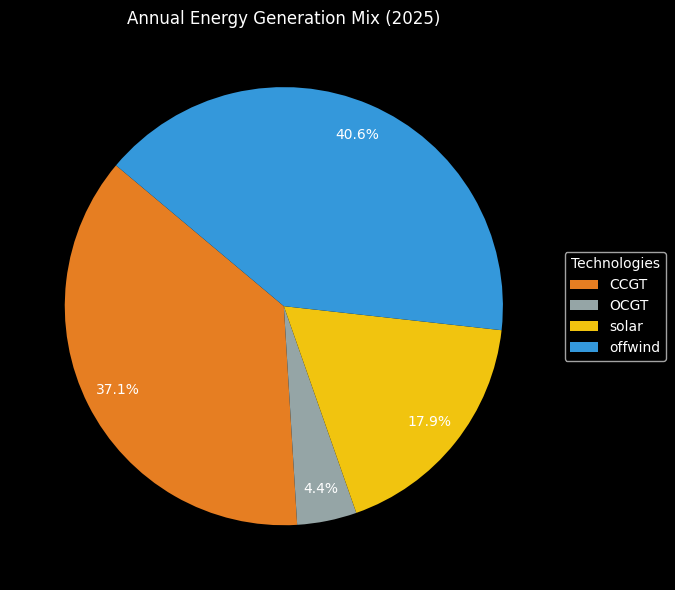

In [18]:
# Select the year you want to plot
year_to_plot = 2025

# 1. Sum across time to get the total annual MWh per technology
# .sum('time') reduces (tech, time) -> (tech)
annual_gen = gen_solutions[year_to_plot].sum('time')

# 2. Convert to Pandas Series to easily access index (tech names) and values
total_gen_filtered = annual_gen.to_series()

# 3. Filter out technologies with zero or negligible production
total_gen_filtered = total_gen_filtered[total_gen_filtered > 0]

# 4. Map colors based on the filtered technology list
plot_colors = [colors.get(tech, '#bdc3c7') for tech in total_gen_filtered.index]

# 5. Plot Pie
fig, ax = plt.subplots(figsize=(10, 6))
wedges, texts, autotexts = ax.pie(
    total_gen_filtered,
    autopct='%1.1f%%',
    startangle=140,
    colors=plot_colors,
    pctdistance=0.85
)

ax.legend(
    wedges,
    total_gen_filtered.index,
    title="Technologies",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

ax.set_title(f'Annual Energy Generation Mix ({year_to_plot})')
plt.tight_layout()
plt.show()

Plot duration curves

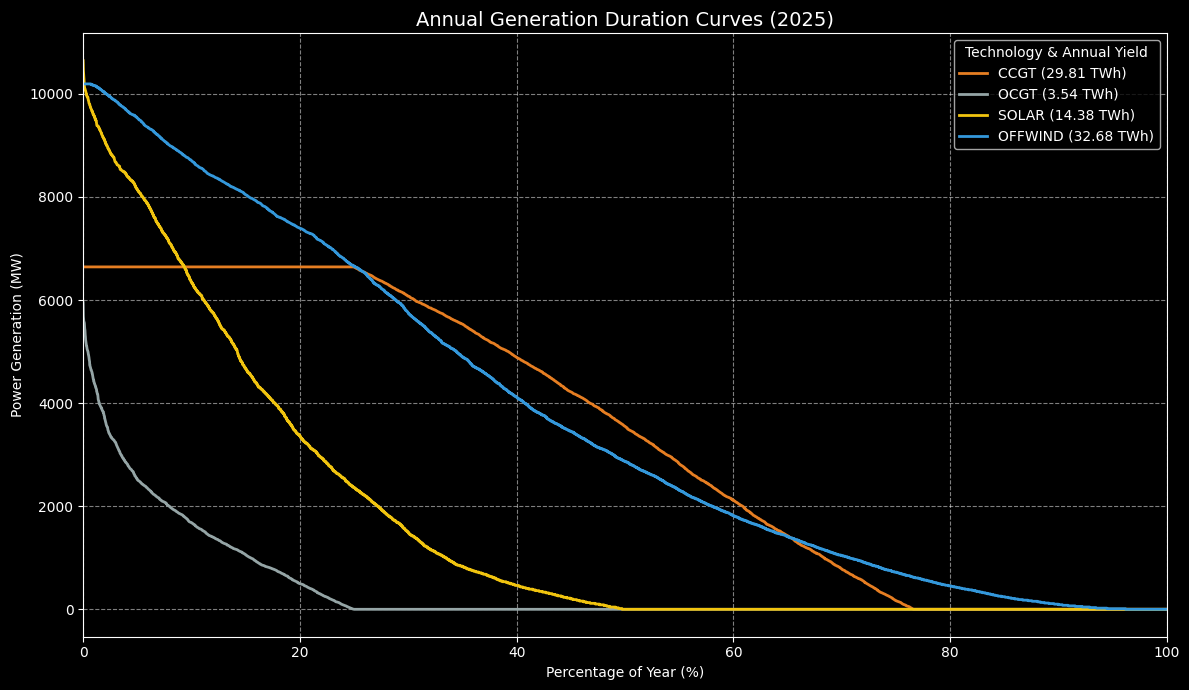

In [19]:
# 1. Select the year and convert the DataArray to a pandas DataFrame (transposed to time x tech)
year_to_plot = 2025
gen_df = gen_solutions[year_to_plot].to_pandas().T

# 2. Calculate annual sums for the labels
annual_sums = gen_df.sum()

# 3. Filter for technologies with > 0 production
active_techs = annual_sums[annual_sums > 0].index

fig, ax = plt.subplots(figsize=(12, 7))

for tech in active_techs:
    # Sort hourly data descending (this is the essence of a duration curve)
    data = gen_df[tech].sort_values(ascending=False).values

    # Create x-axis as percentage of time
    x_axis = np.linspace(0, 100, len(data))

    # Plotting
    ax.plot(x_axis, data,
            label=f"{tech.upper()} ({annual_sums[tech]/1e6:.2f} TWh)",
            color=colors.get(tech, '#bdc3c7'),
            linewidth=2)

# Formatting
ax.set_title(f'Annual Generation Duration Curves ({year_to_plot})', fontsize=14)
ax.set_ylabel('Power Generation (MW)')
ax.set_xlabel('Percentage of Year (%)')
ax.set_xlim(0, 100)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title="Technology & Annual Yield", loc='upper right')

plt.tight_layout()
plt.show()

**b) Investigate how sensitive your results are to the interannual variability of solar and wind generation.
Plot the average capacity and variability obtained for every generator using different weather years**

In [20]:
yearly_cf_s, yearly_cf_on, yearly_cf_off

({2023: np.float64(0.11980833333333335),
  2024: np.float64(0.11928927595628415),
  2025: np.float64(0.1145966894977169)},
 {2023: np.float64(0.2118832191780822),
  2024: np.float64(0.18112101548269582),
  2025: np.float64(0.1844824200913242)},
 {2023: np.float64(0.4202721461187215),
  2024: np.float64(0.3747301912568306),
  2025: np.float64(0.3738347031963471)})

In [21]:
capacity_mean = df_res.mean(axis=1)
capacity_std = df_res.std(axis=1)

## Part C)


In [22]:
import linopy as lp
import xarray as xr
import pandas as pd

# 1. Setup Model and Data
m = lp.Model()
time = df_merged['utc_time']
techs = df_techno['technology'].to_list() 

capital_costs = xr.DataArray(df_techno['Annualized_CAPEX_(EUR/MW/yr)'].values, coords=[techs], dims=['tech'])
marginal_costs = xr.DataArray(df_techno['Marginal_Cost_(EUR/MWh)'].values, coords=[techs], dims=['tech'])

tech_efficiency_map = df_techno.set_index('technology')['efficiency']
CF = []
for t in techs:
    if t == 'onwind':
        CF.append(df_merged['onshore_wind_cf'])
    elif t == 'offwind':
        CF.append(df_merged['offshore_wind_cf'])
    elif t == 'solar':
        CF.append(df_merged['solar_cf'])
    else:
        CF.append([0.9]*len(time))

cf = xr.DataArray(CF, coords=[techs, time], dims=['tech', 'time'])
demand = xr.DataArray(df_merged['total_load'], coords=[time], dims=['time'])

# --- NEW: Battery Parameters ---
# You will need to map these to your new dictionaries/dataframes. 
# Using placeholders here so the logic runs.
batt_power_capex = 24678  # EUR/MW/yr
batt_energy_capex = 12894 # EUR/MWh/yr
batt_eff = 0.96 # Charge/Discharge efficiency 

# 2. Variables
# Existing Generator Variables
capacity = m.add_variables(coords=[techs], dims=['tech'], name='capacity', lower=0)
gen = m.add_variables(coords=[techs, time], dims=['tech', 'time'], name='gen', lower=0)

# --- NEW: Battery Variables ---
batt_p_cap = m.add_variables(name='batt_power_cap', lower=0) # MW (Inverter size)
batt_e_cap = m.add_variables(name='batt_energy_cap', lower=0) # MWh (Storage size)
charge = m.add_variables(coords=[time], dims=['time'], name='charge', lower=0) # MW
discharge = m.add_variables(coords=[time], dims=['time'], name='discharge', lower=0) # MW
soc = m.add_variables(coords=[time], dims=['time'], name='soc', lower=0) # MWh

# 3. Constraints
# --- UPDATED: Energy Balance ---
# Generation + Battery Discharge - Battery Charge must equal demand
m.add_constraints((gen.sum('tech') + discharge - charge == demand), name='balance')

# Existing Capacity Constraint
m.add_constraints((gen <= capacity * cf), name='cap_limit')

# --- NEW: Battery Constraints ---
# Power and Energy Limits
m.add_constraints((charge <= batt_p_cap), name='batt_charge_limit')
m.add_constraints((discharge <= batt_p_cap), name='batt_discharge_limit')
m.add_constraints((soc <= batt_e_cap), name='batt_soc_limit')

# State of Charge (SOC) Tracking
# xarray's .roll(time=1) links t to t-1 and nicely wraps the end of the year to the beginning, 
# ensuring a cyclical storage balance without manual boundary conditions.
soc_prev = soc.roll(time=1)
m.add_constraints(
    (soc == soc_prev + charge * batt_eff - discharge / batt_eff), 
    name='batt_soc_track'
)

# 4. Objective Function
# --- UPDATED: Minimize Total Costs including Battery CAPEX ---
obj = (
    (capacity * 3 * capital_costs).sum() + 
    (gen * marginal_costs).sum().sum() +
    (batt_p_cap * 3 * batt_power_capex) + 
    (batt_e_cap * 3 * batt_energy_capex)
)
m.add_objective(obj)

# 5. Solve
m.solve(solver_name='highs')

Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 153.91it/s]


('ok', 'optimal')

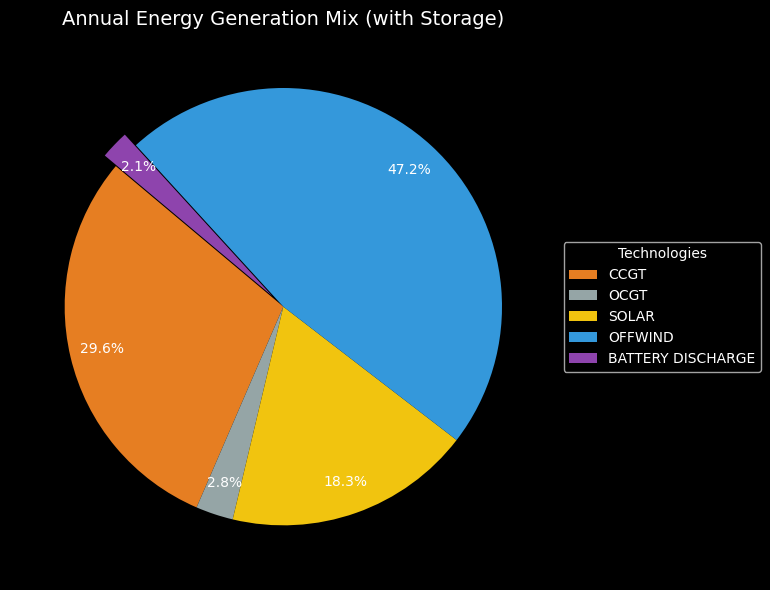

In [23]:
# 1. Extract total annual generation for standard technologies
# Sum across the time dimension and convert to a pandas series
total_gen = m.solution.gen.sum('time').to_series()

# 2. Extract and add total annual battery discharge
# We only add discharge here because it contributes to meeting the demand
total_discharge = m.solution.discharge.sum().item()
if total_discharge > 0:
    total_gen['Battery Discharge'] = total_discharge

# 3. Filter out technologies with zero production
total_gen_filtered = total_gen[total_gen > 0]

# 4. Define colors for the plot
# Ensure 'Battery Discharge' is in your color dictionary
colors['Battery Discharge'] = '#8e44ad' # Purple for Battery
plot_colors = [colors.get(tech, '#bdc3c7') for tech in total_gen_filtered.index]

# 5. Plotting the Pie Chart
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare labels (clean up underscores and uppercase)
labels = [tech.replace('_', ' ').upper() for tech in total_gen_filtered.index]

# Plot Pie
wedges, texts, autotexts = ax.pie(
    total_gen_filtered,
    autopct='%1.1f%%',
    startangle=140,
    colors=plot_colors,
    pctdistance=0.85,
    # Explode the battery slice slightly to highlight the new technology
    explode=[0.07 if 'Battery' in tech else 0 for tech in total_gen_filtered.index]
)

# Add legend to the side
ax.legend(
    wedges,
    labels,
    title="Technologies",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

ax.set_title('Annual Energy Generation Mix (with Storage)', fontsize=14)
plt.tight_layout()
plt.show()

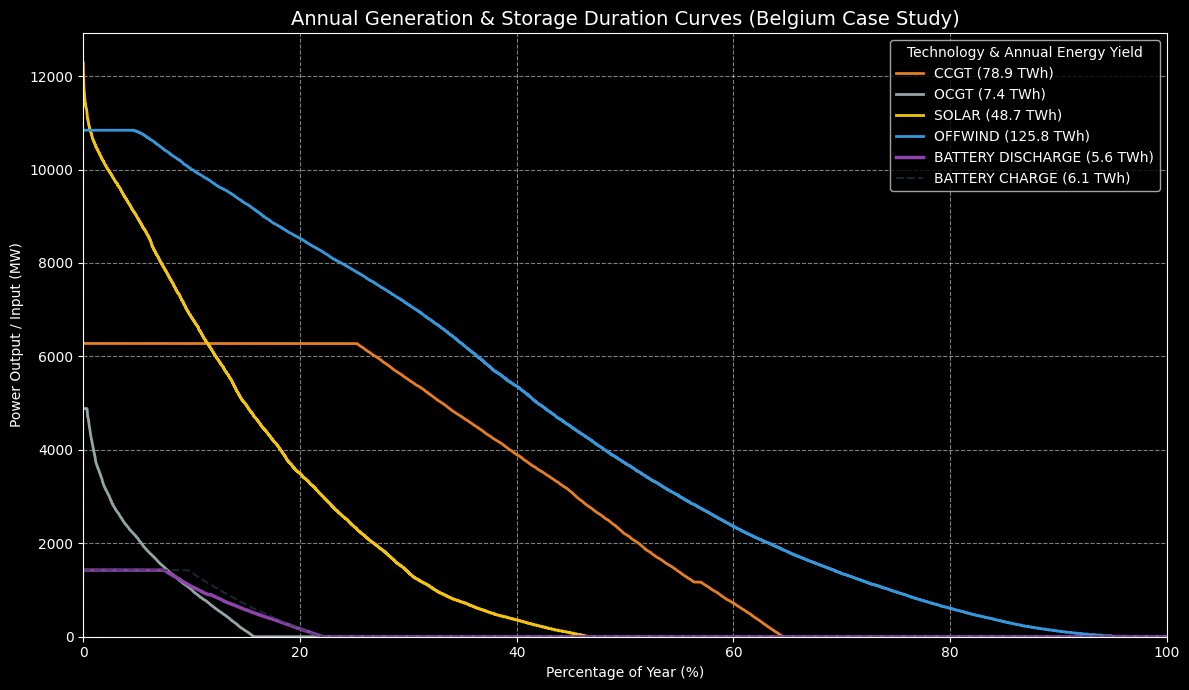

In [24]:
import matplotlib.pyplot as plt

# Extracting results for the specific period (Example: Annual)
# Replace these with your data extraction logic if using a helper function
gen_results = m.solution.gen.to_pandas().T
gen_results['Battery Discharge'] = m.solution.discharge.to_series()
gen_results['Battery Charge'] = m.solution.charge.to_series()

# Define colors for new components
colors['Battery Discharge'] = '#8e44ad' # Purple
colors['Battery Charge'] = '#2c3e50'    # Dark Grey/Blue

# Filter active technologies
annual_sums = gen_results.sum()
active_techs = [t for t in annual_sums.index if annual_sums[t] > 0 and t != 'Battery Charge']

fig, ax = plt.subplots(figsize=(12, 7))

for tech in active_techs:
    # Sort data descending to create a Duration Curve
    data = gen_results[tech].sort_values(ascending=False).values
    x_axis = np.linspace(0, 100, len(data))

    ax.plot(x_axis, data,
            label=f"{tech.upper()} ({annual_sums[tech]/1e6:.1f} TWh)",
            color=colors.get(tech, '#bdc3c7'),
            linewidth=2.5 if 'Battery' in tech else 2)

# Plot Battery Charge as a dashed line for reference
if annual_sums.get('Battery Charge', 0) > 0:
    charge_data = gen_results['Battery Charge'].sort_values(ascending=False).values
    ax.plot(np.linspace(0, 100, len(charge_data)), charge_data,
            label=f"BATTERY CHARGE ({annual_sums['Battery Charge']/1e6:.1f} TWh)",
            color=colors['Battery Charge'], linestyle='--', alpha=0.6)

# Formatting
ax.set_title('Annual Generation & Storage Duration Curves (Belgium Case Study)', fontsize=14)
ax.set_ylabel('Power Output / Input (MW)')
ax.set_xlabel('Percentage of Year (%)')
ax.set_xlim(0, 100)
ax.set_ylim(bottom=0)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title="Technology & Annual Energy Yield", loc='upper right')

plt.tight_layout()
plt.show()

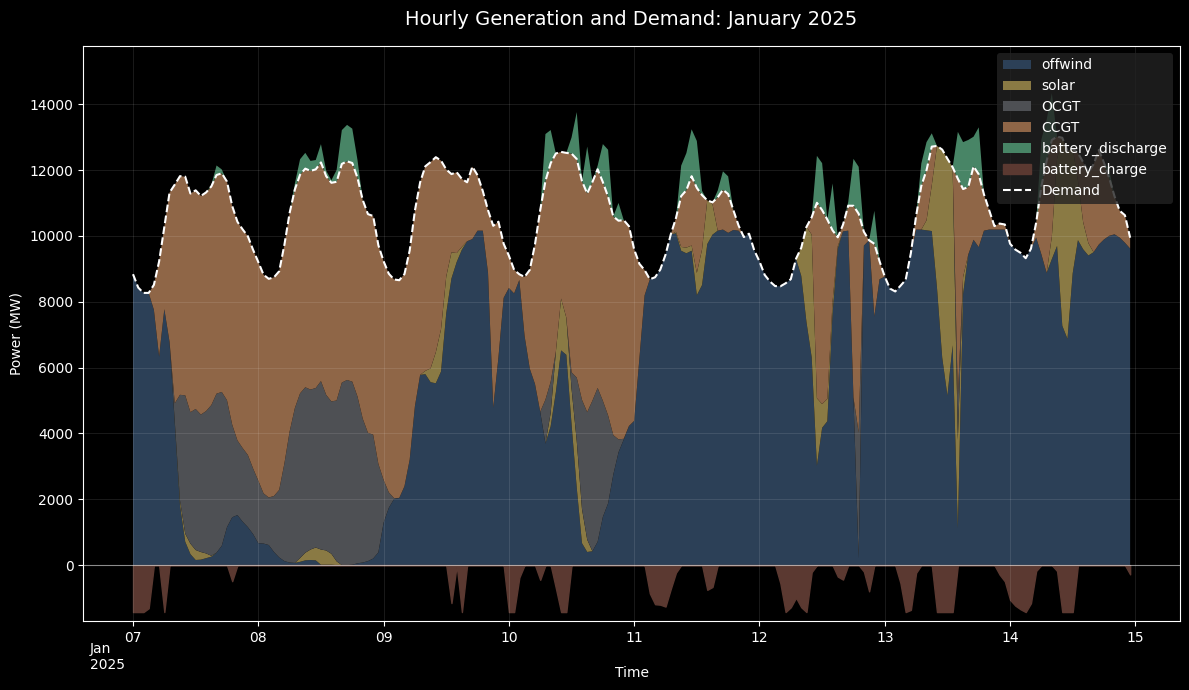

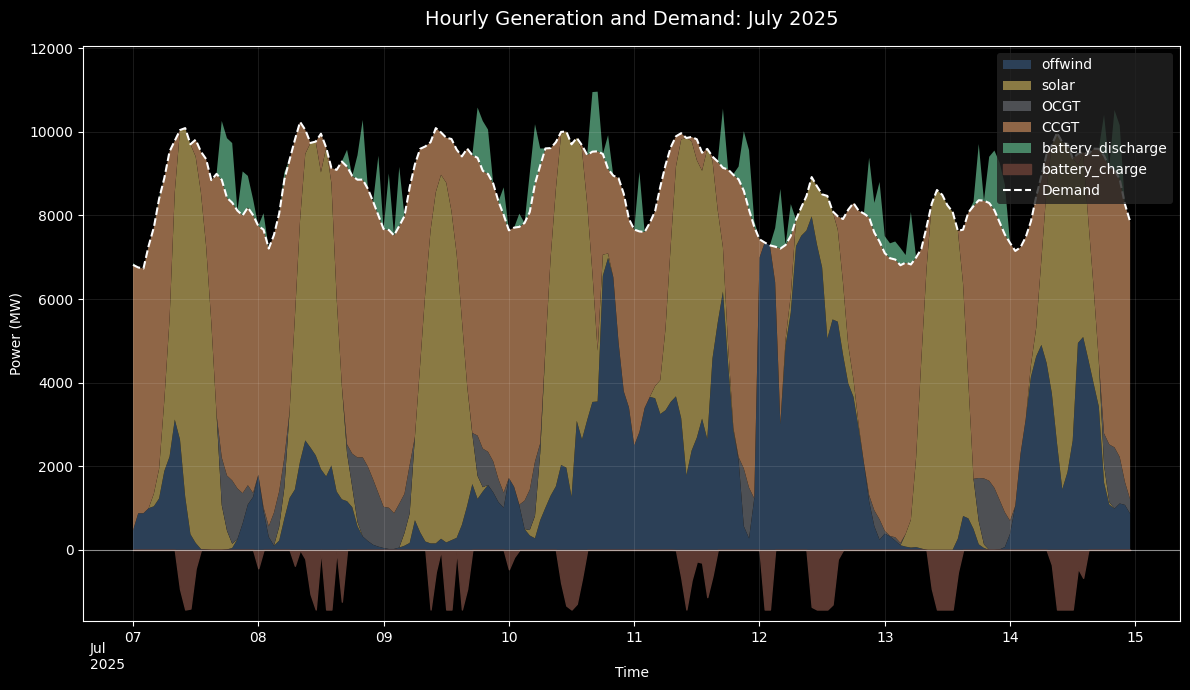

In [25]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set the dark theme globally for this plot
plt.style.use('dark_background')

# 1. Data extraction function tailored for the positive/negative plot
def get_dark_plot_data(gen_var, charge_var, discharge_var, demand_arr, start_date, end_date):
    """
    Extracts and separates positive generation and negative charging for plotting.
    """
    # Slice the data for the specific period
    gen_slice = gen_var.sel(time=slice(start_date, end_date)).to_pandas().T
    demand_slice = demand_arr.sel(time=slice(start_date, end_date)).to_series()
    charge_slice = charge_var.sel(time=slice(start_date, end_date)).to_series()
    discharge_slice = discharge_var.sel(time=slice(start_date, end_date)).to_series()

    # Create the positive stack (All generators + battery discharging)
    positive_gen = gen_slice.copy()
    positive_gen['battery_discharge'] = discharge_slice

    # Fill NaNs with 0 to prevent plotting errors
    positive_gen = positive_gen.fillna(0)
    charge_slice = charge_slice.fillna(0)
    demand_slice = demand_slice.fillna(0)

    return positive_gen, charge_slice, demand_slice


# 2. The custom dark plotting function
def plot_dark_dispatch(positive_gen, charge_data, demand_data, title, date_label):
    """
    Plots a dark-themed area chart with battery charging on the negative Y-axis.
    """
    # Define colors matching the reference image style
    dark_colors = {
        'onwind': '#3F5D7D',            # Dark blue-grey
        'offwind': '#2C4057',           # Darker blue-grey for offshore
        'solar': '#8A7A44',             # Dark ochre
        'OCGT': '#4E5054',              # Dark grey
        'CCGT': '#8F6647',              # Rust-brown
        'nuclear': '#7A3B3B',           # Dark red
        'coal': '#525252',              # Dark grey
        'battery_discharge': '#488566', # Muted green
        'battery_charge': '#5B3931'     # Dark reddish-brown
    }

    fig, ax = plt.subplots(figsize=(12, 7))

    # Identify which technologies actually produced power in this timeframe
    active_techs = [tech for tech in dark_colors.keys() if tech in positive_gen.columns and positive_gen[tech].sum() > 0]

    # --- PLOT POSITIVE VALUES (Generation + Discharge) ---
    ax.stackplot(positive_gen.index,
                 [positive_gen[tech] for tech in active_techs],
                 labels=active_techs,
                 colors=[dark_colors[tech] for tech in active_techs],
                 alpha=1.0)

    # --- PLOT NEGATIVE VALUES (Battery Charge) ---
    # Linopy outputs charge as positive MW, so we multiply by -1 to plot it downwards
    if charge_data.sum() > 0:
        ax.fill_between(charge_data.index, 0, -charge_data,
                        label='battery_charge',
                        color=dark_colors['battery_charge'],
                        alpha=1.0)

    # --- PLOT DEMAND LINE ---
    ax.plot(demand_data.index, demand_data,
            label='Demand', color='white', linestyle='--', linewidth=1.5)

    # Add a thin white line at Y=0 for visual clarity
    ax.axhline(0, color='white', linewidth=0.8, alpha=0.5)

    # --- FORMATTING ---
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_ylabel('Power (MW)')
    ax.set_xlabel('Time', labelpad=15)

    # Dynamically set Y-axis limits with some padding
    max_y = max(positive_gen.sum(axis=1).max(), demand_data.max()) * 1.1
    min_y = -charge_data.max() * 1.2 if charge_data.max() > 0 else -1000
    ax.set_ylim(min_y, max_y)

    # X-Axis formatting (Show day numbers)
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))

    # Add Month/Year annotation at the bottom left
    ax.annotate(date_label, xy=(0, 0), xycoords=('axes fraction', 'axes fraction'),
                xytext=(5, -15), textcoords='offset points', va='top', ha='left',
                fontsize=10, color='white')

    # Legend formatting
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc='upper right', bbox_to_anchor=(1, 1),
              fontsize=10, facecolor='#222222', edgecolor='none', labelcolor='white')

    # Subtle grid
    ax.grid(True, linestyle='-', alpha=0.1, color='white')
    
    plt.tight_layout()
    plt.show()

# --- Execution (Updated Dates for January and July) ---

# Extract data for a week in January 2025
pos_gen, batt_charge, base_demand = get_dark_plot_data(
    gen_solutions[2025], 
    charge.solution,       # Direct linopy variable
    discharge.solution,    # Direct linopy variable
    demand_data[2025], 
    '2025-01-07', '2025-01-14' # <--- Updated to match non-battery plot
)

# Plot the graph for Winter
plot_dark_dispatch(
    pos_gen, 
    batt_charge, 
    base_demand, 
    'Hourly Generation and Demand: January 2025', 
    'Jan\n2025'
)

# Extract data for a week in July 2025
jul_pos_gen, jul_batt_charge, jul_base_demand = get_dark_plot_data(
    gen_solutions[2025], 
    charge.solution,       # Direct linopy variable
    discharge.solution,    # Direct linopy variable
    demand_data[2025], 
    '2025-07-07', '2025-07-14' # <--- Matches non-battery plot
)

# Plot the graph for Summer
plot_dark_dispatch(
    jul_pos_gen, 
    jul_batt_charge, 
    jul_base_demand, 
    'Hourly Generation and Demand: July 2025', 
    'Jul\n2025'
)

In [26]:
# 6. Results Extraction (Updated for Storage)

# Standard Generation Results
opt_capacity = capacity.solution.to_series()
total_gen = gen.solution.sum('time').to_series()
total_cost = m.objective.value

# Battery Storage Results
# Extracting scalar values for the optimized capacities (Updated to match new variable names)
opt_storage_p = float(batt_p_cap.solution)
opt_storage_e = float(batt_e_cap.solution)

# Extracting total annual battery activity
total_discharge = discharge.solution.sum().item()
total_charge = charge.solution.sum().item()

# Add Battery Discharge to the generation report for a complete view
total_gen['Battery Discharge'] = total_discharge

# Calculate Storage Duration (Hours)
storage_duration = opt_storage_e / opt_storage_p if opt_storage_p > 0 else 0

# --- PRINTING RESULTS ---

print(f"Total System Cost: {total_cost:,.2f} EUR")

print("\n--- Generation & Storage Discharge (Annual MWh) ---")
for tech, value in total_gen.items():
    print(f"{tech:20}: {value:15,.2f} MWh")

print("\n--- Optimal Generation Capacities (MW) ---")
print(opt_capacity)

print("\n--- Optimal Battery Storage Capacities ---")
print(f"Power Capacity (Inverter) : {opt_storage_p:10,.2f} MW")
print(f"Energy Capacity (Battery) : {opt_storage_e:10,.2f} MWh")
print(f"Optimized Storage Duration: {storage_duration:10,.2f} hours")

print("\n--- Battery Efficiency & Losses ---")
print(f"Total Charged Energy      : {total_charge:15,.2f} MWh")
print(f"Total Discharged Energy   : {total_discharge:15,.2f} MWh")
print(f"System Round-trip Losses  : {total_charge - total_discharge:15,.2f} MWh")

Total System Cost: 15,540,883,352.94 EUR

--- Generation & Storage Discharge (Annual MWh) ---
CCGT                :   78,881,379.83 MWh
OCGT                :    7,380,196.60 MWh
solar               :   48,677,658.20 MWh
onwind              :            0.00 MWh
offwind             :  125,758,873.39 MWh
nuclear             :            0.00 MWh
coal                :            0.00 MWh
Battery Discharge   :    5,615,221.08 MWh

--- Optimal Generation Capacities (MW) ---
tech
CCGT        6974.736607
OCGT        5426.439401
solar      15770.680944
onwind        -0.000000
offwind    11797.487245
nuclear        0.000000
coal           0.000000
Name: solution, dtype: float64

--- Optimal Battery Storage Capacities ---
Power Capacity (Inverter) :   1,426.12 MW
Energy Capacity (Battery) :   6,881.18 MWh
Optimized Storage Duration:       4.83 hours

--- Battery Efficiency & Losses ---
Total Charged Energy      :    6,092,904.81 MWh
Total Discharged Energy   :    5,615,221.08 MWh
System Round-tr